In [49]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy.signal import medfilt


class RocketFeatureExtractor:
    def __init__(
        self,
        hand="Right",
        orig_fps=30.0,
        target_fps=None,          # None → no downsampling
        window_sec=3.0,
        step_sec=1.0,
    ):
        self.hand = hand
        self.orig_fps = float(orig_fps)
        self.target_fps = float(target_fps) if target_fps is not None else None

        self.downsample = target_fps is not None
        self.effective_fps = self.target_fps if self.downsample else self.orig_fps

        self.dt_orig = 1.0 / self.orig_fps
        self.dt_effective = 1.0 / self.effective_fps

        self.window_size = int(window_sec * self.effective_fps)
        self.step_size = int(step_sec * self.effective_fps)

    def _calculate_channels(self, dfh):

        channels_per_segment = []

        def get_pts(df, lm_prefix):
            cols = [f"{lm_prefix}_{ax}_smooth" for ax in ["x", "y"]]
            return df[cols].values

        for seg_id, df_seg in dfh.groupby("segment_id"):

            if len(df_seg) < self.window_size:
                continue
                
            # pts: (T, 2)
            pts0 = get_pts(df_seg, "lm_0")   # Wrist
            pts5 = get_pts(df_seg, "lm_5")   # Index
            pts17 = get_pts(df_seg, "lm_17") # Pinky

            # --- 1. Velocity & Acceleration (Wrist) ---
            v_vec = np.diff(pts0, axis=0, prepend=pts0[:1]) / self.dt_orig
            v_mag = np.linalg.norm(v_vec, axis=1)
            
            # Acceleration is orthogonal to Velocity
            accel = np.diff(v_vec, axis=0, prepend=v_vec[:1]) / self.dt_orig
            a_mag = np.linalg.norm(accel, axis=1)

            # --- 2. Curvature (Path Shape) ---
            # Curvature measures how much the path deviates from a straight line.
            # High curvature at high speed is an expert 'arc'.
            # High curvature at low speed is a novice 'tremor/hesitation'.
            dx = v_vec[:, 0]
            dy = v_vec[:, 1]
            ddx = accel[:, 0]
            ddy = accel[:, 1]
            
            # Adding a small epsilon to avoid division by zero
            numerator = np.abs(dx * ddy - dy * ddx)
            denominator = (dx**2 + dy**2)**1.5 + 1e-6
            curvature = numerator / denominator

            # --- 3. Pose Dynamics (Index-Pinky relationship) ---
            # Orientation Angle
            v_orient = pts5 - pts0
            angles = np.arctan2(v_orient[:, 1], v_orient[:, 0])
            d_angle = np.diff(np.unwrap(angles), prepend=angles[0]) / self.dt_orig

            # Area Dynamics (The 'Fumble' factor)
            v1 = pts5 - pts0
            v2 = pts17 - pts0
            palm_area = 0.5 * np.abs(v1[:, 0] * v2[:, 1] - v1[:, 1] * v2[:, 0])
            # Rate of area change - orthogonal to the area itself
            d_area = np.diff(palm_area, prepend=palm_area[0]) / self.dt_orig

            # --- 4. Final Stack (6 Channels) ---
            # We use Log-transform on Curvature and Accel because they are heavy-tailed
            channels_orig = np.stack([
                v_mag, 
                np.log1p(a_mag), 
                np.log1p(curvature), 
                d_angle, 
                palm_area, 
                d_area
            ], axis=1)
            
            # Final Median Filter pass for derivative noise
            for c in range(channels_orig.shape[1]):
                channels_orig[:, c] = medfilt(channels_orig[:, c], kernel_size=3)

            # --- Optional downsampling ---
            if not self.downsample:
                channels_per_segment.append(channels_orig)
                continue

            n_steps = int(
                len(channels_orig) * (self.target_fps / self.orig_fps)
            )
            if n_steps < self.window_size:
                continue

            t_orig = np.arange(len(channels_orig)) * self.dt_orig
            t_target = np.arange(n_steps) * self.dt_effective

            f_chan = interp1d(
                t_orig,
                channels_orig,
                axis=0,
                kind="linear",
                fill_value="extrapolate",
            )

            channels_target = f_chan(t_target)
            channels_per_segment.append(channels_target)

        return channels_per_segment

    def prepare_rocket_windows(self, df_dict):
        all_windows = []
        video_mapping = []

        for key, df in tqdm(df_dict.items(), desc="Slicing ROCKET Windows"):
            dfh = df[df["hand_label"] == self.hand].copy()
            if len(dfh) < self.window_size:
                continue

            segment_signals = self._calculate_channels(dfh)

            for seg_signal in segment_signals:
                T = len(seg_signal)
                if T < self.window_size:
                    continue

                for start in range(
                    1, T - self.window_size + 1, self.step_size
                ):
                    end = start + self.window_size
                    window = seg_signal[start:end]

                    # ROCKET expects (Channels, Time)
                    all_windows.append(window.T)
                    video_mapping.append(key)

        return np.array(all_windows), video_mapping


In [50]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

In [51]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:   0%|          | 0/86 [00:00<?, ?it/s]

Loading processed data:  97%|█████████▋| 83/86 [00:04<00:00, 16.91it/s]


In [76]:
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import RobustScaler

# 1. Initialize and Prepare Data
extractor = RocketFeatureExtractor(hand="Right", window_sec=3.0, step_sec=1.0)
X_windows, video_mapping = extractor.prepare_rocket_windows(df_dict)

N_tr, C, T = X_windows.shape

X_windows_flat = X_windows.transpose(0, 2, 1).reshape(-1, C)
    
    # Fit and Transform
scaler = RobustScaler()
X_windows_flat = scaler.fit_transform(X_windows_flat)
X_windows_flat = np.clip(X_windows_flat, -15, 15)

X_windows = X_windows_flat.reshape(N_tr, T, C).transpose(0, 2, 1)

# 2. Generate ROCKET Features (The "Brute Force" part)
# This will turn your 5 channels into ~10,000 features
rocket = MiniRocketMultivariate(random_state=29)
X_win_feats = rocket.fit_transform(X_windows)

# 3. Predict Residuals
# Let's say 'df_results' contains your MAE 5.0 predictions
# residuals = actual_scores - predicted_scores

# Merge ROCKET features with your residual labels using 'keys'
# and run a Ridge Regression. 
# If the R2 score is > 0.1, you have found a local signal!

Slicing ROCKET Windows:   0%|          | 0/83 [00:00<?, ?it/s]

Slicing ROCKET Windows: 100%|██████████| 83/83 [00:09<00:00,  8.57it/s]


In [77]:
X_win_feats.shape

(30598, 9996)

In [78]:
X_win_feats[range(10)].describe()

,0,1,2,3,4,5,6,7,8,9
count,30598.000000,30598.000000,30598.000000,30598.000000,30598.000000,30598.000000,30598.000000,30598.000000,30598.000000,30598.000000
mean,0.347358,0.700505,0.200115,0.486669,0.877538,0.315307,0.559432,0.097269,0.400826,0.764980
std,0.120996,0.138512,0.154653,0.055990,0.140208,0.134580,0.068844,0.125121,0.093430,0.154898
min,0.000000,0.355556,0.000000,0.277778,0.388889,0.000000,0.300000,0.000000,0.055556,0.366667
25%,0.266667,0.588889,0.055556,0.444444,0.800000,0.211111,0.511111,0.000000,0.344444,0.644444
50%,0.366667,0.688889,0.188889,0.488889,0.933333,0.333333,0.555556,0.044444,0.411111,0.766667
75%,0.444444,0.811111,0.333333,0.522222,1.000000,0.422222,0.611111,0.155556,0.466667,0.900000
max,0.688889,1.000000,0.644444,0.744444,1.000000,0.688889,0.822222,0.588889,0.688889,1.000000


# First do it with little data leakage in PCA (much faster than doing PCA and K-means within each fold)

In [79]:
# BoW helper functions to move elsewhere late


import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm # Assuming tqdm is available for progress tracking

# --- 1. SETUP: Replace with your actual data and scaling process ---

# Assuming this list contains all N_total x 6 feature vectors, scaled and clipped
# This is equivalent to your all_window_features_flat *after* scaling/clipping
# You will likely extract this from your MILBagDataset object's internal structure.
# Example: all_window_features_flat_scaled = np.concatenate(self.bags) 

# Assuming you already have:
# all_window_features_flat_scaled: (N_total, D) array of all window features (D=6 in your case), already scaled/clipped
# self.bags: A list of numpy arrays, where each array is (N_i, D) for video i
# self.bag_ids: A list of identifiers for each video (e.g., [('Video1', 'S1'), ('Video2', 'S2'), ...])

# --- 2. Hyperparameters ---
K_CLUSTERS = 20  # Start between 20 and 50. K=30 is a good default.
RANDOM_SEED = 42
N_INIT = 3 # Number of times to initialize K-Means

def generate_bow_features(all_window_features_flat_scaled, bags_list, bag_ids):
    """
    Applies K-Means clustering to all windows (the vocabulary) and then
    creates a histogram (BoW vector) for each video (bag).

    Args:
        all_window_features_flat_scaled (np.ndarray): (N_total, D) array of all scaled window features.
        bags_list (list): List of (N_i, D) np.ndarrays for each video.
        bag_ids (list): List of video identifiers.

    Returns:
        pd.DataFrame: A DataFrame where rows are videos and columns are BoW cluster counts.
    """
    
    # --- Step A: Train the K-Means Model (The Vocabulary) ---
    print(f"Fitting K-Means model with K={K_CLUSTERS}...")
    
    # Use MiniBatchKMeans for potentially faster training on large window sets
    kmeans = MiniBatchKMeans(
        n_clusters=K_CLUSTERS,
        init='k-means++',
        n_init=N_INIT,
        random_state=RANDOM_SEED,
        # Set max_iter higher if convergence is an issue
    )
    
    kmeans.fit(all_window_features_flat_scaled)

    all_cluster_assignments = kmeans.predict(all_window_features_flat_scaled)
    
    print("K-Means fit complete. Generating histograms...")

    # --- Step B: Generate Histograms (The BoW Feature Vectors) ---
    bow_features = []

    for bag_array, bag_id in tqdm(zip(bags_list, bag_ids), total=len(bags_list), desc="Generating BoW Histograms"):
        
        # 1. Quantization: Predict the cluster for every window in the current bag
        # Output is (N_i,) array of cluster indices (0 to K-1)
        cluster_assignments = kmeans.predict(bag_array)
        
        # 2. Histogram: Count the frequency of each cluster index
        # The result is the BoW feature vector for this video
        histogram, _ = np.histogram(
            cluster_assignments,
            bins=np.arange(K_CLUSTERS + 1), # Bins from 0 up to K_CLUSTERS
            density=False # Count, not probability
        )
        
        # Normalize the histogram by the number of windows in the video
        # This makes the feature robust to differences in video length
        total_windows = len(bag_array)
        bow_vector = histogram / (total_windows + 1e-6) # Use a small constant for safety
        
        bow_features.append(bow_vector)

    # Create column names (e.g., 'BoW_0', 'BoW_1', ...)
    col_names = [f'BoW_{i}' for i in range(K_CLUSTERS)]
    
    bow_df = pd.DataFrame(bow_features, columns=col_names, index=pd.MultiIndex.from_tuples(bag_ids, names=['VideoName', 'SurgeonID']))
    
    print("BoW feature generation complete.")
    return bow_df, all_cluster_assignments, kmeans

# Example Usage (You will integrate this into your existing pipeline):
# 1. Get the scaled data: 
#    If using your MILBagDataset, you will need to aggregate the scaled bags:
#    all_window_features_flat_scaled = np.concatenate([bag.cpu().numpy() for bag, _, _ in dataset]) 
#    bags_list = [bag.cpu().numpy() for bag, _, _ in dataset]
#    bag_ids = [bag_id for _, _, bag_id in dataset]

# 2. Run the function:
# bow_df = generate_bow_features(all_window_features_flat_scaled, bags_list, bag_ids)
# print(bow_df.head())

# 3. Hybrid Regression:
# X_global = your_global_pca_features_df
# X_hybrid = pd.concat([X_global, bow_df], axis=1)
# Train your LMM/XGBoost on X_hybrid


import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA # PCA for t-SNE initialization

def visualize_cluster_assignment(
    all_window_features_flat_scaled, 
    all_cluster_assignments, 
    K_CLUSTERS=None, 
    method='UMAP', 
    N_SAMPLES=5000,
    is_discrete=True
):
    """
    Applies either t-SNE or UMAP to the window features, coloring points by their K-Means 
    cluster assignment to validate the clustering quality.

    Args:
        all_window_features_flat_scaled (np.ndarray): (N_total, D) array of all scaled window features.
        all_cluster_assignments (np.ndarray): (N_total,) array of cluster indices (0 to K-1).
        K_CLUSTERS (int): The total number of clusters used in K-Means.
        method (str): Choose 'UMAP' or 'TSNE'. Defaults to 'UMAP'.
        N_SAMPLES (int): Number of random samples to plot (recommended for large N_total).
    """
    method = method.upper()
    if method not in ['UMAP', 'TSNE']:
        raise ValueError("Method must be 'UMAP' or 'TSNE'.")

    N_total = all_window_features_flat_scaled.shape[0]
    
    if N_total == 0:
        print("Error: Input features array is empty.")
        return

    # --- 1. Sampling for Performance ---
    if N_total > N_SAMPLES:
        print(f"Dataset size ({N_total}) is large. Sampling {N_SAMPLES} points for visualization...")
        
        rng = np.random.default_rng(seed=42)
        sample_indices = rng.choice(N_total, N_SAMPLES, replace=False)
        
        X_sample = all_window_features_flat_scaled[sample_indices]
        Y_sample = all_cluster_assignments[sample_indices]
    else:
        print(f"Using all {N_total} points for visualization.")
        X_sample = all_window_features_flat_scaled
        Y_sample = all_cluster_assignments

    # Convert to DataFrame for easier handling and plotting metadata
    df_sample = pd.DataFrame(X_sample)
    df_sample['Cluster_ID'] = Y_sample
    df_sample['Cluster_ID'] = df_sample['Cluster_ID'].astype('category')
    
    # --- 2. Dimensionality Reduction ---
    
    print(f"Computing {method} embeddings (this may take a few moments)...")
    
    if method == 'UMAP':
        reducer = umap.UMAP(
            n_neighbors=15, 
            min_dist=0.1, 
            n_components=2, 
            random_state=42
        )
        # Using tqdm for progress tracking during the fit_transform
        # UMAP can be slow, so we provide some feedback
        with tqdm(total=100, desc="UMAP Progress", unit="iter") as pbar:
            embedding = reducer.fit_transform(df_sample.drop(columns=['Cluster_ID']))
            pbar.update(100) # Simple completion flag
        title = f'UMAP of Window Features (N={len(df_sample)})'

    elif method == 'TSNE':
        # Apply PCA first for initialization, which is standard practice for t-SNE
        # and helps with convergence speed/quality, especially with higher dimensional inputs.
        pca_dim = min(50, X_sample.shape[1]) 
        X_pca = PCA(n_components=pca_dim, random_state=42).fit_transform(X_sample)
        
        tsne = TSNE(
            n_components=2, 
            learning_rate='auto', 
            init='pca', 
            perplexity=30, # Adjust perplexity (often 5 to 50)
            random_state=42, 
            n_jobs=-1
        )
        embedding = tsne.fit_transform(X_pca)
        title = f't-SNE of Window Features (N={len(df_sample)})'

    df_sample['X'] = embedding[:, 0]
    df_sample['Y'] = embedding[:, 1]
    
        # --- 3. Plotting ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    color_vals = df_sample['Cluster_ID'].values

    if is_discrete:
        # ----- DISCRETE CASE (clusters) -----
        unique_vals = np.unique(color_vals)
        num_vals = len(unique_vals)

        # Map values to range 0..num_vals-1 for consistent coloring
        value_to_index = {v: i for i, v in enumerate(unique_vals)}
        mapped = np.vectorize(value_to_index.get)(color_vals)

        cmap = plt.cm.get_cmap("tab20", num_vals)
        scatter = ax.scatter(
            df_sample['X'], df_sample['Y'],
            c=mapped,
            cmap=cmap,
            marker='.',
            alpha=0.8
        )

        # Discrete colorbar
        cbar = fig.colorbar(
            scatter, ax=ax, ticks=np.arange(num_vals)
        )
        cbar.set_ticklabels(unique_vals)
        cbar.set_label("Cluster ID")

    else:
        # ----- CONTINUOUS CASE (scores) -----
        scatter = ax.scatter(
            df_sample['X'], df_sample['Y'],
            c=color_vals,
            cmap="viridis",
            marker='.',
            alpha=0.8
        )
        # Continuous colorbar
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label("Score")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(f'{method} Dimension 1')
    ax.set_ylabel(f'{method} Dimension 2')

    plt.tight_layout()
    plt.show()

In [80]:
# PCA Dimensionality Reduction without scaling (PPV features)

from sklearn.decomposition import PCA

n = 50  # Number of principal components to keep
X_win_pca = PCA(n_components=n).fit_transform(X_win_feats)

In [81]:
X_win_pca.shape


(30598, 50)

In [82]:
from sklearn.cluster import MiniBatchKMeans
from tqdm import tqdm

N_CLUSTERS = 40
RANDOM_SEED = 42
N_INIT = 3

print(f"Fitting K_Means model with K={N_CLUSTERS}")

kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    init='k-means++',
    n_init=N_INIT,
    random_state=RANDOM_SEED
)

kmeans.fit(X_win_pca)
#all_cluster_assignments = kmeans.predict(X_win_pca)

print("K-Means fit complete. Generating histograms...")

bow_features = []

for vid_name in (tqdm(set(video_mapping), desc="Generating BoW Histograms")):
    mask = [v == vid_name for v in video_mapping]
    bag_array = X_win_pca[mask]
    
    cluster_assignments = kmeans.predict(bag_array)
    
    histogram, _ = np.histogram(
        cluster_assignments,
        bins=np.arange(N_CLUSTERS + 1),
        density=False
    )
    
    total_windows = len(bag_array)
    bow_vector = histogram / (total_windows + 1e-6)
    
    bow_features.append(bow_vector)

# Create column names (e.g., 'BoW_0', 'BoW_1', ...)
col_names = [f'BoW_{i}' for i in range(N_CLUSTERS)]

bow_df = pd.DataFrame(bow_features, columns=col_names, index=pd.MultiIndex.from_tuples(set(video_mapping), names=['VideoName', 'SurgeonID']))
#bow_df['VideoName'] = [v[0] for v in set(video_mapping)]
#bow_df['SurgeonID'] = [v[1] for v in set(video_mapping)]

print("BoW feature generation complete.")


Fitting K_Means model with K=40
K-Means fit complete. Generating histograms...


Generating BoW Histograms: 100%|██████████| 83/83 [00:00<00:00, 192.30it/s]

BoW feature generation complete.


Using all 83 points for visualization.
Computing UMAP embeddings (this may take a few moments)...


UMAP Progress:   0%|          | 0/100 [00:00<?, ?iter/s]/Users/finnweikert/opt/anaconda3/envs/env-ml/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP Progress: 100%|██████████| 100/100 [00:00<00:00, 393.85iter/s]


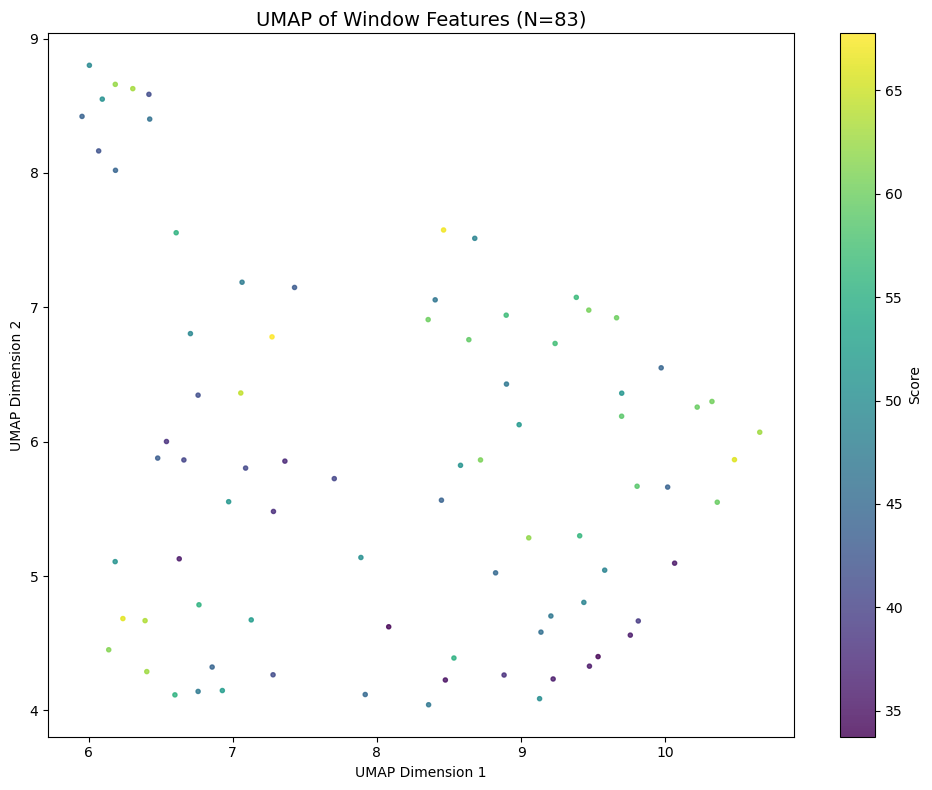

In [83]:
bow_df = bow_df.sort_index()
X_bow = bow_df.values
bag_scores = [v for v in grs_scores.values()]


visualize_cluster_assignment(X_bow, np.array(bag_scores), is_discrete=False)

In [84]:
bow_df.describe()

,BoW_0,BoW_1,BoW_2,BoW_3,BoW_4,BoW_5,BoW_6,BoW_7,BoW_8,BoW_9,...,BoW_30,BoW_31,BoW_32,BoW_33,BoW_34,BoW_35,BoW_36,BoW_37,BoW_38,BoW_39
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,...,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,0.023273,0.016640,0.031525,0.032334,0.028469,0.040059,0.029008,0.032388,0.016249,0.025429,...,0.025769,0.027469,0.056520,0.014622,0.025361,0.017439,0.018577,0.015045,0.030235,0.015456
std,0.019126,0.024983,0.013316,0.031909,0.018704,0.064224,0.020277,0.027019,0.012331,0.016716,...,0.020089,0.020031,0.032877,0.008381,0.013436,0.009473,0.008108,0.008011,0.042700,0.007070
min,0.000000,0.000000,0.004000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,...,0.000000,0.000000,0.000000,0.000000,0.004219,0.000000,0.000000,0.000000,0.000000,0.002342
25%,0.009403,0.000000,0.022259,0.011668,0.014504,0.000000,0.012700,0.009464,0.007253,0.013246,...,0.012309,0.015522,0.031164,0.008634,0.015479,0.011156,0.013573,0.009434,0.000000,0.010738
50%,0.017621,0.005848,0.028213,0.020408,0.023697,0.012170,0.025210,0.023697,0.011990,0.022099,...,0.021552,0.022453,0.052795,0.013158,0.024169,0.016393,0.017341,0.013587,0.016447,0.014124
75%,0.031082,0.019146,0.042073,0.039526,0.039083,0.057222,0.041373,0.052183,0.022460,0.034952,...,0.034084,0.033515,0.076110,0.017583,0.033847,0.022566,0.024415,0.019466,0.046408,0.019729
max,0.090909,0.106195,0.082278,0.151786,0.083900,0.308057,0.105882,0.118738,0.058824,0.103004,...,0.111607,0.106464,0.158301,0.040816,0.059278,0.046296,0.044944,0.036585,0.259259,0.036281


In [85]:
#shuffle scores
import random
#random.seed(42)
#random.shuffle(bag_scores)


# standardize the data using standard scaler
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

scaler = StandardScaler()
X_bow_scaled = scaler.fit_transform(X_bow)

scaled_bow_df = pd.DataFrame(X_bow_scaled, columns=bow_df.columns, index=bow_df.index)
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
pearson_corrs = []
spearman_corrs = []
for i in range(X_bow_scaled.shape[1]):
    pearson_corr, _ = pearsonr(X_bow_scaled[:, i], np.array(bag_scores))
    spearman_corr, _ = spearmanr(X_bow_scaled[:, i], np.array(bag_scores))
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 BoW features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]
for idx in top_pearson_indices:
    print(f"BoW_{idx}: Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 BoW features by Pearson correlation:
BoW_28: Pearson r = -0.4909, Spearman rho = -0.4670
BoW_4: Pearson r = -0.4489, Spearman rho = -0.4832
BoW_29: Pearson r = -0.4158, Spearman rho = -0.4059
BoW_34: Pearson r = -0.3700, Spearman rho = -0.3867
BoW_7: Pearson r = -0.3663, Spearman rho = -0.3106
BoW_11: Pearson r = 0.3438, Spearman rho = 0.3459
BoW_33: Pearson r = -0.3232, Spearman rho = -0.2974
BoW_32: Pearson r = 0.3028, Spearman rho = 0.2796
BoW_21: Pearson r = 0.2989, Spearman rho = 0.2300
BoW_17: Pearson r = -0.2970, Spearman rho = -0.2843
BoW_3: Pearson r = 0.2667, Spearman rho = 0.2831
BoW_31: Pearson r = -0.2628, Spearman rho = -0.1891


=========================================================================== ===========================================================================

=========================================================================== ===========================================================================

=========================================================================== ===========================================================================

In [86]:
# load 
df_metrics = pd.read_csv("data/metrics/best_global_metrics2.csv")
df_metrics.head()



,Participant Number,GRS_Total,QRS_Overal,Case_Number,adjusted_total_path_Right,total_duration_Right,num_reversals_Right,velocity_corr,interhand_dist_change_rms,mean_abs_angle_change_Right
0,1,59.25,48.50,1,62034.389107,534.933333,737,0.300569,37.862266,0.726575
1,1,54.40,45.00,2,37353.044239,288.033333,378,0.642479,37.941429,0.899482
2,1,74.50,60.50,3,51364.691660,423.033333,694,0.476772,39.133227,0.929110
3,2,49.25,39.25,1,103592.752300,1281.533333,1571,0.356040,23.805603,0.726725
4,2,49.00,38.00,2,74343.087367,1010.833333,1133,0.475344,21.928832,0.714639


In [87]:
bow_df.reset_index(['VideoName', 'SurgeonID'], inplace=True)

In [88]:

df_combined = pd.merge(bow_df, df_metrics, left_index=True, right_index=True)

In [89]:

global_features = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
rocket_features = [f'BoW_{i}' for i in range(N_CLUSTERS)]

# for each of the features correlation with QRS_Overal
for feature in global_features + rocket_features:
    corr = df_combined[feature].corr(df_combined['QRS_Overal'])
    print(f"Correlation between {feature} and QRS_Overal: {corr:.4f}")

Correlation between adjusted_total_path_Right and QRS_Overal: -0.7176
Correlation between total_duration_Right and QRS_Overal: -0.6843
Correlation between num_reversals_Right and QRS_Overal: -0.7203
Correlation between velocity_corr and QRS_Overal: -0.0071
Correlation between BoW_0 and QRS_Overal: 0.1119
Correlation between BoW_1 and QRS_Overal: -0.1840
Correlation between BoW_2 and QRS_Overal: 0.0474
Correlation between BoW_3 and QRS_Overal: 0.2667
Correlation between BoW_4 and QRS_Overal: -0.4489
Correlation between BoW_5 and QRS_Overal: 0.0287
Correlation between BoW_6 and QRS_Overal: -0.2407
Correlation between BoW_7 and QRS_Overal: -0.3663
Correlation between BoW_8 and QRS_Overal: 0.0236
Correlation between BoW_9 and QRS_Overal: -0.2078
Correlation between BoW_10 and QRS_Overal: -0.1427
Correlation between BoW_11 and QRS_Overal: 0.3438
Correlation between BoW_12 and QRS_Overal: 0.0852
Correlation between BoW_13 and QRS_Overal: -0.1523
Correlation between BoW_14 and QRS_Overal: -0.

In [90]:
# leakage free version:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.linear_model import Ridge, RidgeCV

def leakage_free_residual_analysis(
    df,
    candidate_features,
    target='QRS_Overal',
    surgeon_col='Participant Number',
    pcs_to_use=[0, 1, 2],
    pca_features=['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
):
    """
    Evaluates candidate features by identifying their contribution to residuals
    using a Leave-One-Surgeon-Out cross-validation approach.
    """
    unique_surgeons = df[surgeon_col].unique()
    fold_results = []

    for surgeon_out in tqdm(unique_surgeons, desc="Analyzing Folds"):
        # Split Data
        df_train = df[df[surgeon_col] != surgeon_out].dropna(subset=[target] + candidate_features + pca_features).copy()
        
        # 1. Baseline PCA & Model (Fit on Train ONLY)
        scaler = StandardScaler()
        X_train_pca_raw = scaler.fit_transform(df_train[pca_features])
        
        pca = PCA(n_components=max(pcs_to_use) + 1)
        train_pcs = pca.fit_transform(X_train_pca_raw)
        
        # Define baseline columns
        pc_cols = [f'PC{i+1}' for i in range(train_pcs.shape[1])]
        df_train[pc_cols] = train_pcs
        used_pc_cols = [pc_cols[i] for i in pcs_to_use]
        
        # 2. Baseline Model (Train residuals)
        y_train = df_train[target].values
        pc_model = Ridge(alpha=0.5)
        pc_model.fit(df_train[used_pc_cols], y_train)
        
        train_residuals = y_train - pc_model.predict(df_train[used_pc_cols])
        pc_resid_var = np.var(train_residuals)

        # 3. Evaluate Candidate Features on this Fold
        for feat in candidate_features:
            # Partial R2 calculation on train set
            X_full = df_train[used_pc_cols + [feat]]
            full_model = Ridge(alpha=0.5)
            full_model.fit(X_full, y_train)
            
            full_resid_var = np.var(y_train - full_model.predict(X_full))
            partial_r2 = 1 - (full_resid_var / pc_resid_var)
            
            # Correlation with residuals
            r, _ = pearsonr(df_train[feat], train_residuals)
            
            fold_results.append({
                'Fold_Surgeon_Out': surgeon_out,
                'Feature': feat,
                'Partial_R2': partial_r2,
                'Resid_Corr': r
            })

    # ==============================
    # 4. Aggregate Results across all folds
    # ==============================
    results_df = pd.DataFrame(fold_results)
    
    # We want to know:
    # 1. Mean Partial R2
    # 2. Selection Frequency (how often is it in the top 10?)
    summary = results_df.groupby('Feature').agg({
        'Partial_R2': ['mean', 'std'],
        'Resid_Corr': ['mean', 'std']
    }).reset_index()
    
    summary.columns = ['Feature', 'Mean_Partial_R2', 'Std_Partial_R2', 'Mean_Resid_Corr', 'Std_Resid_Corr']

    results_df['Resid_Corr'] = results_df['Resid_Corr'].abs()
    
    # Calculate "Stability": How often was this feature in the top 10 of its fold?
    results_df['Rank'] = results_df.groupby('Fold_Surgeon_Out')['Resid_Corr'].rank(ascending=False)
    stability = results_df[results_df['Rank'] <= 1]['Feature'].value_counts() / len(unique_surgeons)
    stability = stability.rename('Selection_Stability').reset_index().rename(columns={'index': 'Feature'})
    
    final_summary = summary.merge(stability, on='Feature', how='left').fillna(0)
    
    return final_summary.sort_values('Mean_Partial_R2', ascending=False)

# Usage:

df_res_leakage_free = leakage_free_residual_analysis(df_combined, [col for col in bow_df.columns if col.startswith('BoW_')])
df_res_leakage_free

Analyzing Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Analyzing Folds: 100%|██████████| 28/28 [00:09<00:00,  2.84it/s]


,Feature,Mean_Partial_R2,Std_Partial_R2,Mean_Resid_Corr,Std_Resid_Corr,Selection_Stability
34,BoW_4,0.007750,0.001050,-0.273520,0.017707,0.964286
37,BoW_7,0.007251,0.001117,-0.188624,0.013835,0.000000
15,BoW_22,0.006723,0.001229,-0.201667,0.019833,0.000000
14,BoW_21,0.006659,0.002245,0.143140,0.024604,0.000000
3,BoW_11,0.006429,0.001646,0.138257,0.017133,0.000000
23,BoW_3,0.006325,0.002403,0.154179,0.028237,0.000000
16,BoW_23,0.005008,0.001415,0.132708,0.022278,0.000000
24,BoW_30,0.004947,0.000820,0.206149,0.015323,0.000000
2,BoW_10,0.004770,0.001016,-0.153657,0.016705,0.000000
9,BoW_17,0.004702,0.001229,-0.209717,0.030367,0.000000


In [91]:
# analyse components of the top PC
top_rocket_pc = df_res_leakage_free.iloc[0]['Feature']
top_rocket_pc


'BoW_4'

In [92]:
top_features = df_res_leakage_free[df_res_leakage_free['Selection_Stability'] >= 0.85]['Feature'].tolist()
top_features

['BoW_4']

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 118.02it/s]



          HYBRID MODEL (RIDGE) LOSOCV RESULTS
Overall Correlation (R): 0.7995
Overall MAE: 4.7624
Overall Std Dev of Errors: 3.4996

--- Per-Fold Performance Summary ---
           Train_MAE  Test_MAE  Test_Corr
SurgeonID                                
1           4.333474  5.767814   0.818058
2           4.305778  4.740238   0.675305
3           4.147169  9.910376   0.801521
4           4.353915  5.230756   0.292643
5           4.320512  6.058623   0.975154
6           4.483942  1.171212   0.995385
7           4.174002  9.023635  -0.655200
9           4.372535  5.815847  -0.955045
10          4.397857  4.004897   0.989455
11          4.434221  3.281221  -0.182920
12          4.401337  4.015277  -0.498793
13          4.438377  2.216220   0.914923
14          4.288032  6.521709  -0.539420
15          4.375051  4.447621   0.992664
16          4.180468  9.018325  -0.776513
17          4.476638  1.586998   0.992056
18          4.275583  5.461867  -0.368443
19          4.388683  4.365197 

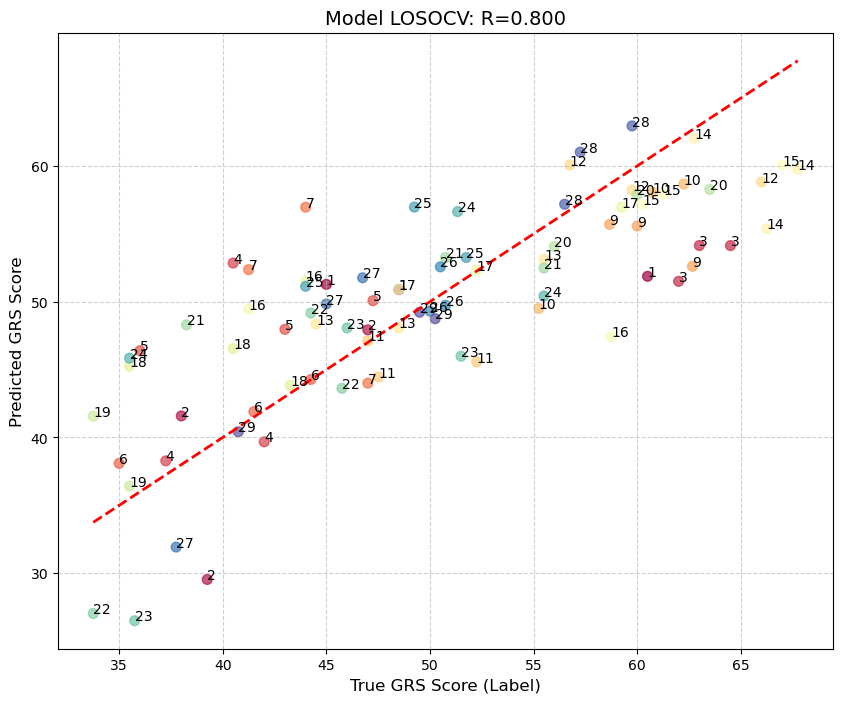

In [93]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data (Code adapted from your input) ---

# --- IMPORTANT ASSUMPTIONS ---
# 1. merged_feature_df is available and c§orrectly indexed.
# 2. 'QRS_Overal' is the column for the true scores (y).
# 3. 'Participant Number' is the column for SurgeonID.
# 4. Feature columns are PC1, PC2, PC3, BoW_2, BoW_20.
# ------------------------------

feature_cols = [col for col in ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']]#, 'velocity_corr']]
additional_feature_cols = ['BoW_4', 'BoW_28'] #['mean_abs_angle_change_Right']#['Rocket_PC27', 'Rocket_PC7', 'Rocket_PC19', 'Rocket_PC5', 'Rocket_PC24', 'Rocket_PC40']  # 'Rocket_PC25', 'Rocket_PC21', 'Rocket_PC22'
all_feature_cols = feature_cols + additional_feature_cols
X = df_combined[all_feature_cols].values
y = df_combined['QRS_Overal'].values

# Extract the Surgeon IDs for the folds
surgeon_ids = df_combined['Participant Number'].values # Assuming 'Participant Number' holds the unique surgeon/participant identifier

unique_surgeons = np.unique(surgeon_ids)
predictions = []
true_scores = []
fold_results = {} # To store results per fold

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

# We will collect fold-level predictions for plotting
all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []


for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # PCA but only on feature_cols
    pca = PCA(n_components=min(3, len(feature_cols)))  # Adjust number of components as needed
    X_train_pca = pca.fit_transform(X_train[:, :len(feature_cols)])
    X_test_pca = pca.transform(X_test[:, :len(feature_cols)])
    
    # component list to keep
    component_list = [0,1,2]  # Keep only the first principal component
    X_train_pca = X_train_pca[:, component_list]
    X_test_pca = X_test_pca[:, component_list]
    
    # Combine PCA features with additional features
    X_train = np.hstack((X_train_pca, X_train[:, len(feature_cols):]))
    X_test = np.hstack((X_test_pca, X_test[:, len(feature_cols):]))

    # 3. Train Model
    # Using the optimized alpha=0.5
    model = Ridge(alpha=0.5)                    # RidgeCV(alphas=np.logspace(-2, 4, 20)). TO CHANGE LATER
    model.fit(X_train, y_train)
    
    # Predict and store
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Fold Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_corr, _ = pearsonr(y_test, y_test_pred)
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_Corr': test_corr
    }
    
    # Store results for overall metrics and plotting
    predictions.extend(y_test_pred)
    true_scores.extend(y_test)
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 4. Evaluate and Print Results ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

# Create a DataFrame for per-fold results
fold_results_df = pd.DataFrame.from_dict(fold_results, orient='index')
fold_results_df.index.name = 'SurgeonID'

print("\n=================================================")
print("          HYBRID MODEL (RIDGE) LOSOCV RESULTS")
print("=================================================")
print(f"Overall Correlation (R): {hybrid_corr:.4f}")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"\n--- Per-Fold Performance Summary ---")
print(fold_results_df)

# --- 5. Visualization ---
plt.figure(figsize=(10, 8))

# Scatter plot
scatter = plt.scatter(
    all_fold_true, 
    all_fold_preds, 
    c=all_fold_surgeons, # Color by surgeon ID
    cmap='Spectral', 
    label='Predicted Scores',
    s=50,
    alpha=0.7
)

for i, sid in enumerate(surgeon_ids):
    plt.annotate(f'{sid}', (all_fold_true[i], all_fold_preds[i]))

# Diagonal Line (Perfect prediction)
plt.plot(
    [min(final_true_scores), max(final_true_scores)], 
    [min(final_true_scores), max(final_true_scores)], 
    'r--', 
    lw=2,
    label='Ideal Prediction (y=x)'
)

plt.xlabel("True GRS Score (Label)", fontsize=12)
plt.ylabel("Predicted GRS Score", fontsize=12)
plt.title(f"Model LOSOCV: R={hybrid_corr:.3f}", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [94]:
# --- 1. Setup ---
# all_rocket_cols should be your full list of candidate features (e.g., all 40+ Rocket PCs)
feature_cols = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
all_rocket_cols = [col for col in df_combined.columns if 'BoW_' in col] 

X_global = df_combined[feature_cols].values
X_rocket = df_combined[all_rocket_cols].values
y = df_combined['QRS_Overal'].values
surgeon_ids = df_combined['Participant Number'].values
unique_surgeons = np.unique(surgeon_ids)

predictions = []
true_scores = []
all_fold_surgeons = []
top_rocket_features_per_fold = {1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8:[], 9: [], 10: []}  # To track top features per fold
all_top_corrs = []

print(f"Starting Leakage-Free LOSOCV (Selection inside the loop)...")

for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    # Split
    test_idx = np.where(surgeon_ids == surgeon_out)[0]
    train_idx = np.where(surgeon_ids != surgeon_out)[0]
    
    # --- A. Scaling (Train only) ---
    scaler = StandardScaler()
    X_train_glob = scaler.fit_transform(X_global[train_idx])
    X_test_glob = scaler.transform(X_global[test_idx])
    
    scaler_r = StandardScaler()
    X_train_rock = scaler_r.fit_transform(X_rocket[train_idx])
    X_test_rock = scaler_r.transform(X_rocket[test_idx])
    
    # --- B. Global PCA (Exactly as before) ---
    pca = PCA(n_components=3)
    X_train_pca = pca.fit_transform(X_train_glob)
    X_test_pca = pca.transform(X_test_glob)
    
    # --- C. Internal Feature Selection (The "Zero-Leakage" Step) ---
    # 1. Fit baseline model to get residuals on training data
    baseline_model = Ridge(alpha=0.5).fit(X_train_pca, y[train_idx])
    train_residuals = y[train_idx] - baseline_model.predict(X_train_pca)
    
    # 2. Find which Rocket features correlate best with training residuals
    # We use Pearson R here as it's the core of your previous residual analysis
    fold_corrs = []
    partial_r2s = []
    for i in range(X_train_rock.shape[1]):
        X_full = X_full = np.column_stack([X_train_pca, X_train_rock[:, i]])
        full_model = LinearRegression().fit(X_full, y[train_idx])
        full_resid = y[train_idx] - full_model.predict(X_full)
        full_resid_var = np.var(full_resid)
        partial_r2 = 1 - (full_resid_var / np.var(train_residuals))
        partial_r2s.append(partial_r2)

        r, _ = pearsonr(X_train_rock[:, i], train_residuals)
        fold_corrs.append(abs(r))
    
    # select features with partial R2 > 0.05 and abs(corr) > 0.2
    """fold_corrs = np.array(fold_corrs)
    partial_r2s = np.array(partial_r2s)
    top_subset_idx = np.where((partial_r2s > 0.05) & (fold_corrs > 0.2))[0]"""

    #for i, idx in enumerate(top_subset_idx):
        #d=1
        #top_rocket_features_per_fold[i+1].append(idx)"""


    # 3. Pick Top 6 features for THIS fold specifically
    top_subset_idx = np.argsort(partial_r2s)[-2:].tolist()
    top_subset_idx.reverse()  # Top 6 indices

    top_corrs = np.array(fold_corrs)[top_subset_idx]
    for c in top_corrs:
        all_top_corrs.append(c)
        if c < 0.15:
            top_subset_idx.remove(top_subset_idx[np.where(top_corrs == c)[0][0]])
            top_corrs = top_corrs[top_corrs != c]


    # DEBUG
    #top_subset_idx = [26, 53, 6]

    for i, idx in enumerate(top_subset_idx):  # reversed to have highest first
        d=1
        #top_rocket_features_per_fold[i+1].append(idx)
    
    # --- D. Combine and Predict ---
    X_train_final = np.hstack((X_train_pca, X_train_rock[:, top_subset_idx]))
    X_test_final = np.hstack((X_test_pca, X_test_rock[:, top_subset_idx]))
    
    # Use your fixed alpha=0.5 Ridge model
    model = Ridge(alpha=0.5)#RidgeCV(alphas=np.logspace(-1, 3, 20))
    model.fit(X_train_final, y[train_idx])
    
    y_test_pred = model.predict(X_test_final)
    
    predictions.extend(y_test_pred)
    true_scores.extend(y[test_idx])
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 2. Evaluation ---
final_predictions = np.array(predictions)
final_true_scores = np.array(true_scores)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_std = np.std(np.abs(final_true_scores - final_predictions))
hybrid_corr, _ = spearmanr(final_true_scores, final_predictions)

print(f"\nFINAL VALID RESULTS:")
print(f"Overall MAE: {hybrid_mae:.4f}")
print(f"Overall Std Dev of Errors: {hybrid_std:.4f}")
print(f"Overall Correlation: {hybrid_corr:.4f}")

Starting Leakage-Free LOSOCV (Selection inside the loop)...


LOSOCV Folds: 100%|██████████| 28/28 [00:02<00:00,  9.52it/s]


FINAL VALID RESULTS:
Overall MAE: 5.8238
Overall Std Dev of Errors: 3.6007
Overall Correlation: 0.6993


# LASSO feature selection

Starting Leave-One-Surgeon-Out CV with 28 folds...


LOSOCV Folds: 100%|██████████| 28/28 [00:02<00:00, 11.90it/s]



          LASSO FEATURE SELECTION RESULTS
Spearman Rho: 0.7275
Pearson R:    0.7214
Overall MAE:  5.2281

--- Most Frequently Selected Features ---
adjusted_total_path_Right    28
num_reversals_Right          28
velocity_corr                28
total_duration_Right         26
Name: count, dtype: int64


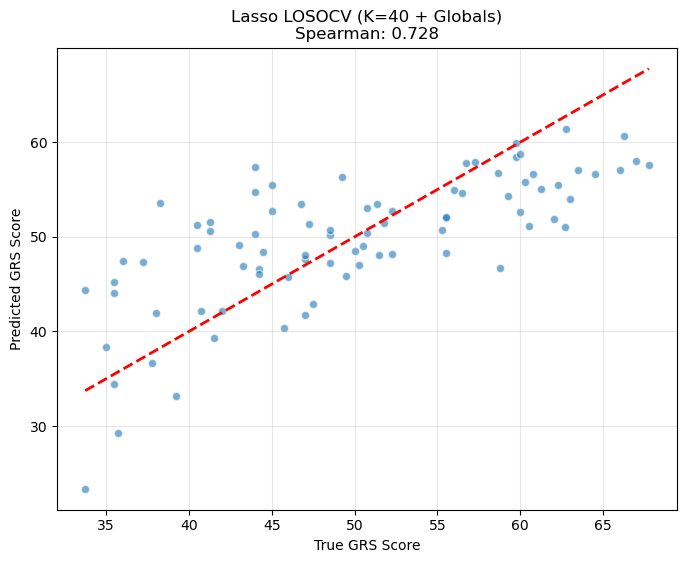

In [95]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Prepare Data ---
# Include ALL BoW columns (e.g., BoW_0 to BoW_39) plus your globals
global_feature_cols = ['adjusted_total_path_Right', 'total_duration_Right', 'num_reversals_Right', 'velocity_corr']
bow_cols = []
all_feature_cols = global_feature_cols + bow_cols

X = df_combined[all_feature_cols].values
y = df_combined['QRS_Overal'].values
surgeon_ids = df_combined['Participant Number'].values 

unique_surgeons = np.unique(surgeon_ids)
fold_results = {} 

all_fold_preds = []
all_fold_true = []
all_fold_surgeons = []

# --- 2. LOSOCV Loop ---
print(f"Starting Leave-One-Surgeon-Out CV with {len(unique_surgeons)} folds...")

for surgeon_out in tqdm(unique_surgeons, desc="LOSOCV Folds"):
    
    # Define Folds
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # 1. Scale all features (StandardScaler is vital for Lasso)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 2. Train LassoCV
    # LassoCV automatically tries different alphas using internal 5-fold CV on the training set
    # to find the optimal sparsity level.
    model = LassoCV(cv=5, random_state=42, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    
    # 3. Predict
    y_test_pred = model.predict(X_test_scaled)

    # Calculate Fold Metrics (Correlation can be NaN for single-sample folds)
    train_mae = mean_absolute_error(y_train, model.predict(X_train_scaled))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    # Track which features Lasso actually kept (non-zero coefficients)
    selected_indices = np.where(model.coef_ != 0)[0]
    selected_names = [all_feature_cols[i] for i in selected_indices]
    
    fold_results[surgeon_out] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Num_Features': len(selected_names),
        'Features': selected_names
    }
    
    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    all_fold_surgeons.extend([surgeon_out] * len(y_test_pred))

# --- 3. Evaluate ---
final_predictions = np.array(all_fold_preds)
final_true_scores = np.array(all_fold_true)

hybrid_mae = mean_absolute_error(final_true_scores, final_predictions)
hybrid_corr_pearson, _ = pearsonr(final_true_scores, final_predictions)
hybrid_corr_spearman, _ = spearmanr(final_true_scores, final_predictions)

print("\n=================================================")
print("          LASSO FEATURE SELECTION RESULTS")
print("=================================================")
print(f"Spearman Rho: {hybrid_corr_spearman:.4f}")
print(f"Pearson R:    {hybrid_corr_pearson:.4f}")
print(f"Overall MAE:  {hybrid_mae:.4f}")

# Optional: Print which features were most commonly selected across folds
all_selected = []
for f in fold_results.values():
    all_selected.extend(f['Features'])
feature_counts = pd.Series(all_selected).value_counts()
print("\n--- Most Frequently Selected Features ---")
print(feature_counts.head(10))

# --- 4. Visualization ---
plt.figure(figsize=(8, 6))
plt.scatter(final_true_scores, final_predictions, alpha=0.6, edgecolors='w')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("True GRS Score")
plt.ylabel("Predicted GRS Score")
plt.title(f"Lasso LOSOCV (K=40 + Globals)\nSpearman: {hybrid_corr_spearman:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

# Check what the BoW features can reach using Recursive Feature Elimination

the result is at least showing that there is information in local signal.

In [96]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.ensemble import RandomForestRegressor

# --- 1. Prepare Data (BoW Only) ---
bow_cols = [col for col in df_combined.columns if col.startswith('BoW_')]
X_bow = df_combined[bow_cols].values
y = df_combined['QRS_Overal'].values
surgeon_ids = df_combined['Participant Number'].values 

unique_surgeons = np.unique(surgeon_ids)
all_fold_preds = []
all_fold_true = []
fold_selected_features = []

print(f"Starting BoW-Only RFE LOSOCV...")

for surgeon_out in tqdm(unique_surgeons, desc="RFE Folds"):
    test_indices = np.where(surgeon_ids == surgeon_out)[0]
    train_indices = np.where(surgeon_ids != surgeon_out)[0]
    
    X_train, X_test = X_bow[train_indices], X_bow[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 2. RFE Selection
    # We use a simple Ridge as the 'ranker' to determine importance
    # We ask RFE to find the best 10 features (adjust as needed)
    estimator = Ridge(alpha=1.0)
    selector = RFE(estimator, n_features_to_select=2, step=1)
    selector = selector.fit(X_train_scaled, y_train)
    
    # 3. Final Prediction with selected BoWs
    # We use RidgeCV on the reduced feature set for better generalization
    X_train_sel = X_train_scaled[:, selector.support_]
    X_test_sel = X_test_scaled[:, selector.support_]
    
    final_model = RidgeCV(alphas=np.logspace(-2, 4, 10))
    final_model.fit(X_train_sel, y_train)
    
    y_test_pred = final_model.predict(X_test_sel)

    all_fold_preds.extend(y_test_pred)
    all_fold_true.extend(y_test)
    
    # Track which BoWs were chosen in this fold
    selected_names = [bow_cols[i] for i in np.where(selector.support_)[0]]
    fold_selected_features.extend(selected_names)

# --- 4. Evaluate Standalone BoW Performance ---
final_predictions = np.array(all_fold_preds)
final_true_scores = np.array(all_fold_true)

standalone_mae = mean_absolute_error(final_true_scores, final_predictions)
standalone_corr, _ = spearmanr(final_true_scores, final_predictions)

print("\n=================================================")
print("        STANDALONE BoW RESULTS (RFE)")
print("=================================================")
print(f"Spearman Rho: {standalone_corr:.4f}")
print(f"Overall MAE:  {standalone_mae:.4f}")

# Check which BoW clusters are 'universal' experts/novice signals
feature_counts = pd.Series(fold_selected_features).value_counts()
print("\n--- Most Stable Local Features (Chosen in most folds) ---")
print(feature_counts.head(10))

Starting BoW-Only RFE LOSOCV...


RFE Folds: 100%|██████████| 28/28 [00:01<00:00, 15.17it/s]


        STANDALONE BoW RESULTS (RFE)
Spearman Rho: 0.6189
Overall MAE:  5.8239

--- Most Stable Local Features (Chosen in most folds) ---
BoW_4     28
BoW_28    28
Name: count, dtype: int64


## Leakage free version (takes long to run)